# Titanic 生还情况数据分析

## 项目背景
Titanic 号沉船事件是经典的数据分析案例。本项目使用 Titanic 乘客数据，探索不同因素与乘客生还情况之间的关联。

## 研究问题
1. 整体生还率是多少？
2. 性别与生还率是否存在关联？
3. 舱位等级与生还率是否存在关联？
4. 年龄、票价和家庭规模与生还率有什么关系？

## 数据说明
数据集包含 891 名 Titanic 乘客的基本信息，包括性别、年龄、舱位等级、票价、家庭成员数量和生还情况等字段。

## 数据质量检查
- `Age` 有 177 个缺失值。
- `Cabin` 有较多缺失值，本项目暂不使用该字段。
- `Embarked` 有 2 个缺失值，本项目暂不将其作为主要分析变量。

In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 1. 整体生还情况

In [98]:
# 总共有多少乘客？
print("1.")
print("总共有",len(df),"名乘客")
# 生还人数多少？
print("2.")
print("生还",df['Survived'].sum(),"名乘客")
# 死亡人数多少？
print("3.")
print("死亡",len(df)-df['Survived'].sum(),"名乘客")
# 总体生还率是多少？
print("4.")
print("总体生还率为：",round(df['Survived'].mean()*100,2),"%")

1.
总共有 891 名乘客
2.
生还 342 名乘客
3.
死亡 549 名乘客
4.
总体生还率为： 38.38 %


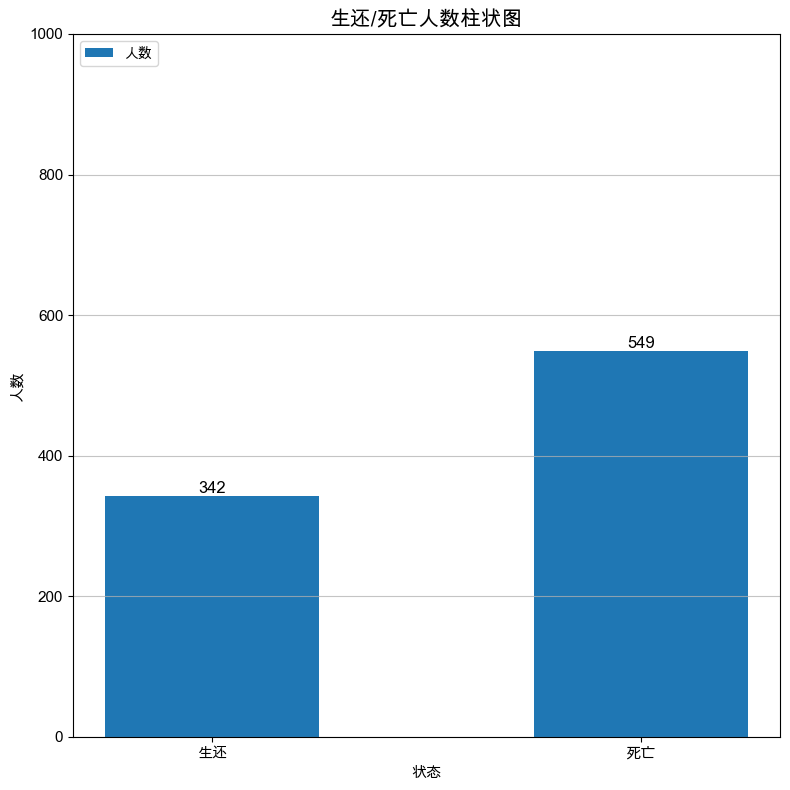

In [50]:
# 生还/死亡人数柱状图
plt.rcParams['font.family'] = "Arial Unicode MS"
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(8,8))
status = ['生还', '死亡']
count = [df['Survived'].sum(), len(df)-df['Survived'].sum()]
plt.bar(status,count,label='人数', width=0.5)
plt.title('生还/死亡人数柱状图', fontsize=15)
plt.xlabel('状态', fontsize=11)
plt.ylabel('人数', fontsize=11)
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.ylim(0,1000)
for x,y in zip(status,count):
    plt.text(x,y,str(y),ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

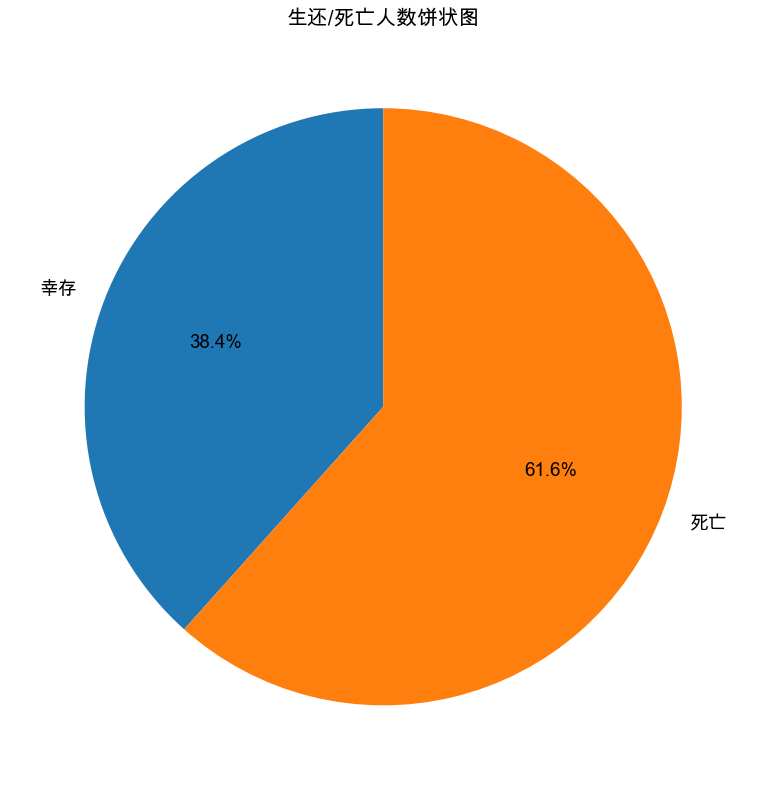

In [59]:
# 生还比例饼图
plt.rcParams['font.family'] = "Arial Unicode MS"
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(8,8))
total = [df['Survived'].sum(), len(df)-df['Survived'].sum()]
status = ['幸存', '死亡']
plt.pie(total,labels=status,autopct='%1.1f%%', startangle=90, textprops={'fontsize':13.5})
plt.title('生还/死亡人数饼状图', fontsize=15)
plt.tight_layout()
plt.show()

## 2. 性别与生还率

In [230]:
# 男性和女性分别有多少人 ？
male_num = len(df[df['Sex'] == 'male'])
female_num = len(df[df['Sex'] == 'female'])
print("1.")
print(f"男性有 {male_num} 人")
print(f"女性有 {female_num} 人")
# 男性生还率是多少 ？
male_survived_count = len(df[(df['Sex'] == 'male') & (df['Survived'] == 1)])
female_survived_count = len(df[(df['Sex'] == 'female') & (df['Survived'] == 1)])
male_survival_rate = male_survived_count / male_num * 100
female_survival_rate = female_survived_count / female_num * 100
print("2.")
print(f"男性生还率是 {male_survival_rate:.2f}%")
# 女性生还率是多少 ？
print("3.")
print(f"女性生还率是 {female_survival_rate:.2f}%")
# 是否体现 "women and children first" ?
df_age_valid = df[df['Age'].notna()]
child_num = len(df_age_valid[df_age_valid['Age'] <= 12])
child_survived_count = len(df_age_valid[(df_age_valid['Survived'] == 1) & (df_age_valid['Age'] <= 12)])
child_survival_rate = child_survived_count / child_num * 100
print("4.")
print(f"儿童生还率是 {child_survival_rate:.2f}%")
print('该样本与“women and children first”有明显关联')


1.
男性有 577 人
女性有 314 人
2.
男性生还率是 18.89%
3.
女性生还率是 74.20%
4.
儿童生还率是 57.97%
该样本与“women and children first”有明显关联


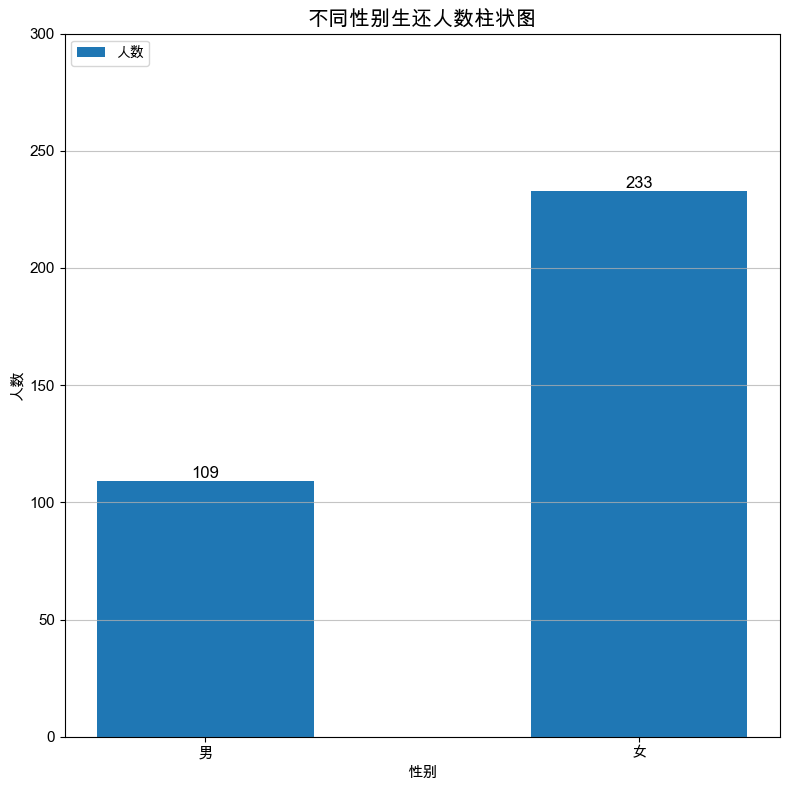

In [103]:
# 不同性别生还人数柱状图
plt.rcParams['font.family'] = "Arial Unicode MS"
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(8,8))
sex = ['男', '女']
count = [male_survived_count, female_survived_count]
plt.bar(sex, count, label='人数', width=0.5)
plt.title('不同性别生还人数柱状图', fontsize=15)
plt.xlabel('性别', fontsize=11)
plt.ylabel('人数', fontsize=11)
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.ylim(0,300)
for x,y in zip(sex, count):
    plt.text(x,y,str(y),ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

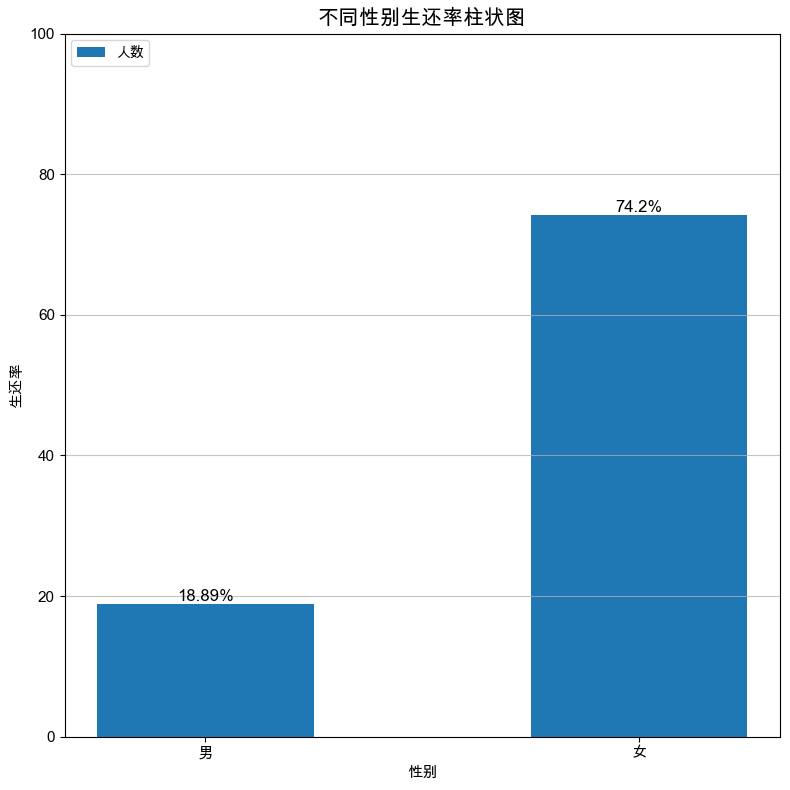

In [144]:
# 不同性别生还率柱状图
plt.rcParams['font.family'] = "Arial Unicode MS"
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(8,8))
sex = ['男', '女']
rate_num = [round(male_survival_rate, 2), round(female_survival_rate, 2)]
rate_text = [str(i) + '%' for i in rate_num]
plt.bar(sex, rate_num, label='生还率', width=0.5)
plt.title('不同性别生还率柱状图', fontsize=15)
plt.xlabel('性别', fontsize=11)
plt.ylabel('生还率', fontsize=11)
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.ylim(0,100)
for x, y, text in zip(sex, rate_num, rate_text):
    plt.text(x,y,text,ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

## 3. 舱位等级与生还率

In [226]:
# 一等舱、二等舱、三等舱人数分别多少？
print("1")
pclass1_total_count = len(df[df['Pclass'] == 1])
pclass2_total_count = len(df[df['Pclass'] == 2])
pclass3_total_count = len(df[df['Pclass'] == 3])
print(f"一等舱的人数为 {pclass1_total_count}")
print(f"二等舱的人数为 {pclass2_total_count}")
print(f"三等舱的人数为 {pclass3_total_count}")
# 哪个舱位生还率最高？
print("2.")
pclass1_survived_count = len(df[(df['Pclass'] == 1) & (df['Survived'] == 1)])
pclass2_survived_count = len(df[(df['Pclass'] == 2) & (df['Survived'] == 1)])
pclass3_survived_count = len(df[(df['Pclass'] == 3) & (df['Survived'] == 1)])

pclass1_survival_rate = round(pclass1_survived_count/pclass1_total_count * 100, 2)
pclass2_survival_rate = round(pclass2_survived_count/pclass2_total_count * 100, 2)
pclass3_survival_rate = round(pclass3_survived_count/pclass3_total_count * 100, 2)
max_survival_rate = max(pclass1_survival_rate, pclass2_survival_rate, pclass3_survival_rate)
if pclass1_survival_rate == max_survival_rate:
    print(f"一等舱生还率 {pclass1_survival_rate}% 最高")
elif pclass2_survival_rate == max_survival_rate:
    print(f"二等舱生还率 {pclass2_survival_rate}% 最高")
else:
    print(f"三等舱生还率 {pclass3_survival_rate}% 最高")
# 舱位等级是否影响生还机会？
print("3.")
if pclass1_survival_rate > pclass2_survival_rate > pclass3_survival_rate:
    print("舱位等级与生还机会有明显关联")
else:
    print("舱位等级与生还机会并无明显关联")

1
一等舱的人数为 216
二等舱的人数为 184
三等舱的人数为 491
2.
一等舱生还率 62.96% 最高
3.
舱位等级与生还机会有明显关联


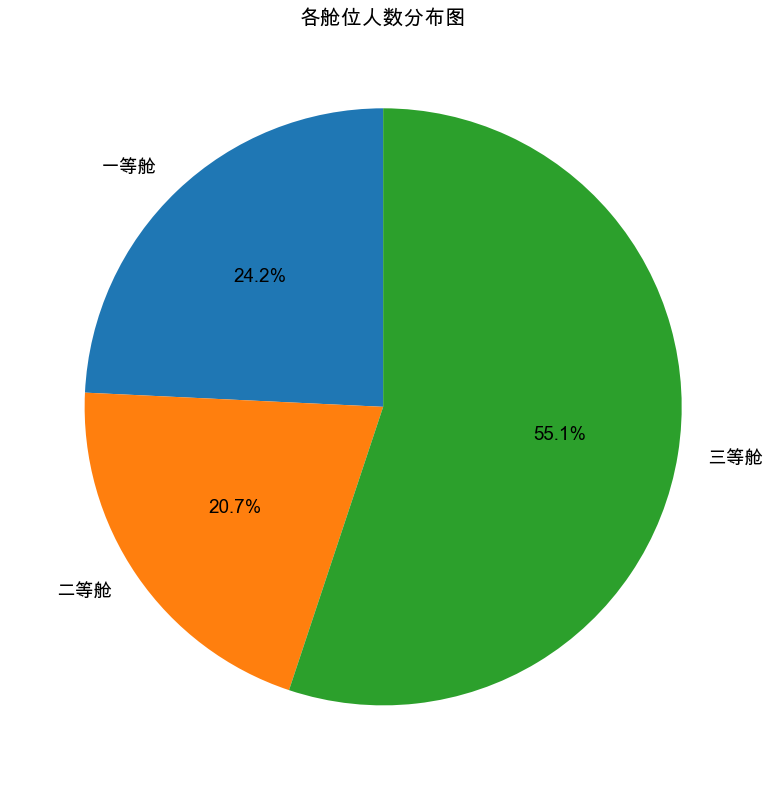

In [139]:
# 各舱位人数分布饼状图
plt.rcParams['font.family'] = "Arial Unicode MS"
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(8,8))
total = [pclass1_total_count, pclass2_total_count, pclass3_total_count]
pclass = ['一等舱', '二等舱', '三等舱']
plt.pie(total, labels=pclass, autopct='%1.1f%%', startangle=90, textprops={'fontsize':13.5})
plt.title('各舱位人数分布图', fontsize=15)
plt.tight_layout()
plt.show()

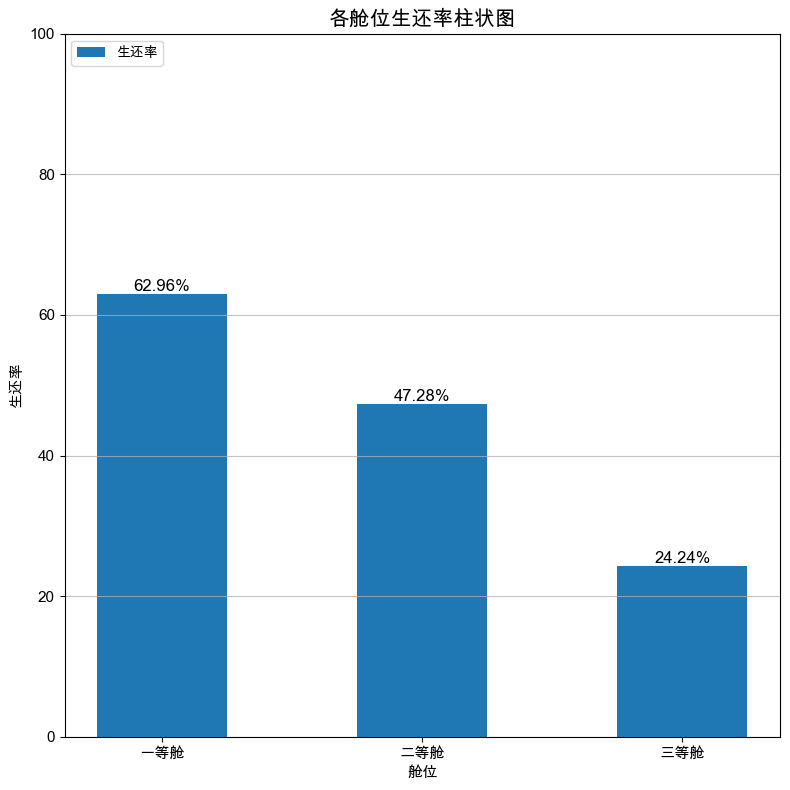

In [141]:
# 各舱位生还率柱状图
plt.rcParams['font.family'] = "Arial Unicode MS"
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(8,8))
pclass_level = ['一等舱', '二等舱', '三等舱']
rate_num = [round(pclass1_survival_rate, 2),
            round(pclass2_survival_rate, 2),
            round(pclass3_survival_rate, 2)]
rate_text = [str(i) + '%' for i in rate_num]
plt.bar(pclass_level, rate_num, label='生还率', width=0.5)
plt.title('各舱位生还率柱状图', fontsize=15)
plt.xlabel('舱位', fontsize=11)
plt.ylabel('生还率', fontsize=11)
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.ylim(0,100)
for x, y, text in zip(pclass_level, rate_num, rate_text):
    plt.text(x,y,text,ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

## 4. 年龄与生还率

说明：年龄分析仅使用年龄信息完整的乘客，因此结论只适用于该部分样本。

In [227]:
# 乘客年龄分布是什么样？
print("1.")
df_age = df.dropna(subset=['Age']).copy()
df_age["Age_group"] = pd.cut(df_age["Age"],
                             bins=[0, 12, 17, 59, 100],
                             labels=["儿童", "青少年", "成年人", "老年人"])
print(df_age["Age_group"].value_counts())
# 儿童是否更容易生还？
print("2.")
teen_num = len(df_age[(df_age['Age'] >=13) & (df_age['Age'] < 18)])
teen_survived_count = len(df_age[(df_age['Survived'] == 1) & (df_age['Age'] >=13) & (df_age['Age'] < 18)])
teen_survival_rate = teen_survived_count / teen_num * 100

adult_num = len(df_age[(df_age['Age'] >=18) & (df_age['Age'] < 60)])
adult_survived_count = len(df_age[(df_age['Survived'] == 1) & (df_age['Age'] >=18) & (df_age['Age'] < 60)])
adult_survival_rate = adult_survived_count / adult_num * 100

elder_num = len(df_age[df_age['Age'] >=60])
elder_survived_count = len(df_age[(df_age['Survived'] == 1) & (df_age['Age'] >=60)])
elder_survival_rate = elder_survived_count / elder_num * 100

if max(child_survival_rate, teen_survival_rate, adult_survival_rate, elder_survival_rate) == child_survival_rate:
    print("儿童更容易生还")
else:
    print("儿童并非生还率最高的年龄组")
# 老年人/成年人/青少年/儿童的生还率有什么差异？
print("3.")
print(f"老年人生还率为 {round(elder_survival_rate, 2)} %")
print(f"成年人生还率为 {round(adult_survival_rate, 2)} %")
print(f"青少年生还率为 {round(teen_survival_rate, 2)} %")
print(f"儿童生还率为 {round(child_survival_rate, 2)} %")
# 年龄缺失值怎么处理？
print("4.")
print("直接删除年龄缺失值的乘客")

1.
Age_group
成年人    575
儿童      69
青少年     44
老年人     26
Name: count, dtype: int64
2.
儿童更容易生还
3.
老年人生还率为 26.92 %
成年人生还率为 38.61 %
青少年生还率为 47.73 %
儿童生还率为 57.97 %
4.
直接删除年龄缺失值的乘客


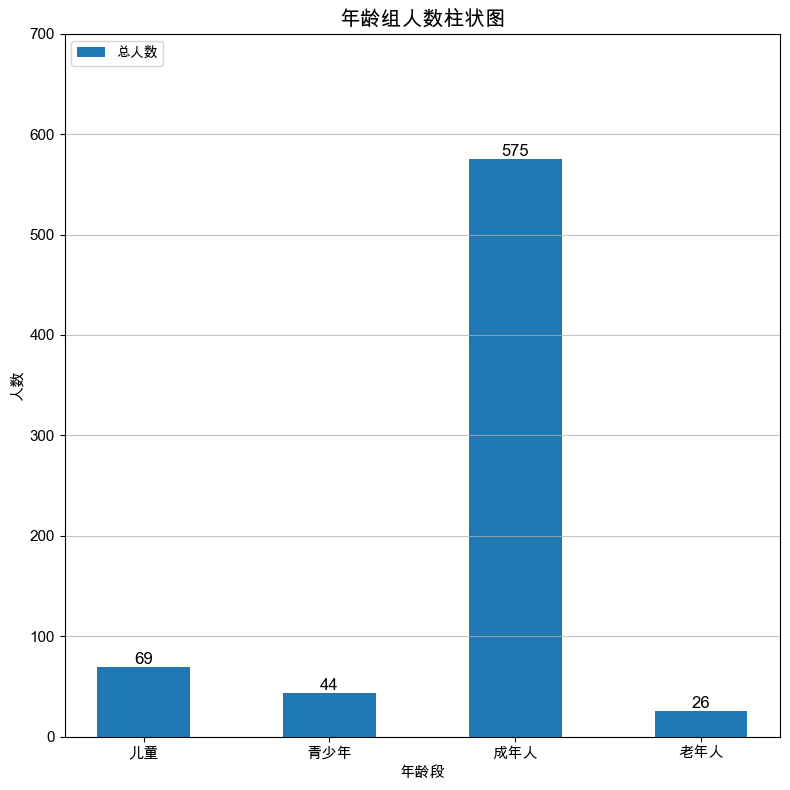

In [229]:
# 年龄直方图
plt.rcParams['font.family'] = "Arial Unicode MS"
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(8,8))
age = ['儿童', '青少年', '成年人', '老年人']
total = [child_num, teen_num, adult_num, elder_num]
plt.bar(age, total, label='总人数', width=0.5)
plt.title('年龄组人数柱状图', fontsize=15)
plt.xlabel('年龄段', fontsize=11)
plt.ylabel('人数', fontsize=11)
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.ylim(0,700)
for x, y in zip(age, total):
    plt.text(x,y,str(y),ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

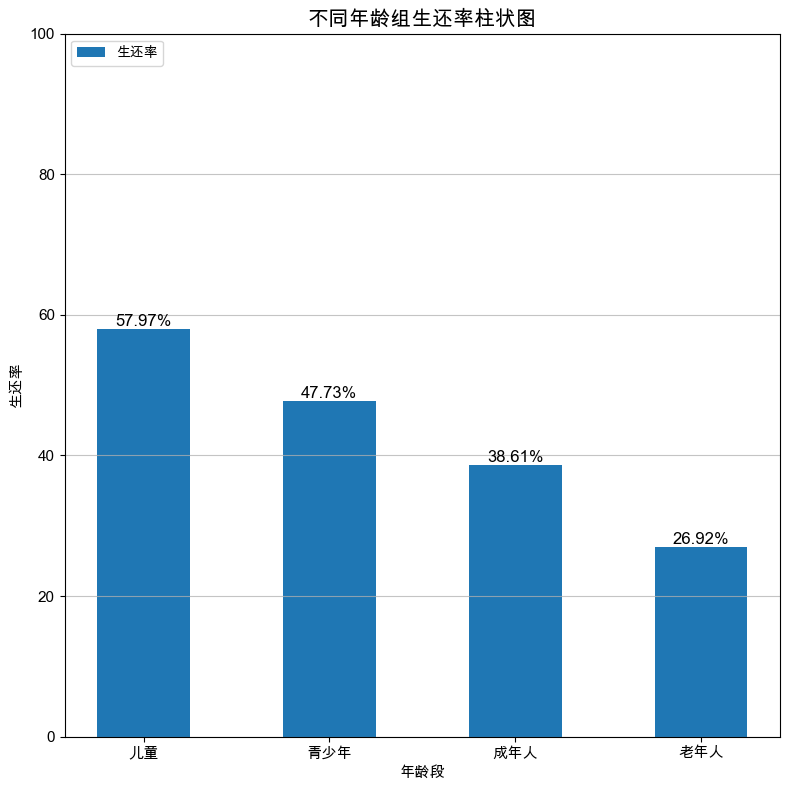

In [182]:
# 不同年龄组生还率柱状图
plt.rcParams['font.family'] = "Arial Unicode MS"
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(8,8))
age = ['儿童', '青少年', '成年人', '老年人']
rate_num = [round(child_survival_rate, 2),
            round(teen_survival_rate, 2),
            round(adult_survival_rate, 2),
            round(elder_survival_rate, 2)]
rate_text = [str(i) + '%' for i in rate_num]
plt.bar(age, rate_num, label='生还率', width=0.5)
plt.title('不同年龄组生还率柱状图', fontsize=15)
plt.xlabel('年龄段', fontsize=11)
plt.ylabel('生还率', fontsize=11)
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.ylim(0,100)
for x, y, text in zip(age, rate_num, rate_text):
    plt.text(x,y,text,ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

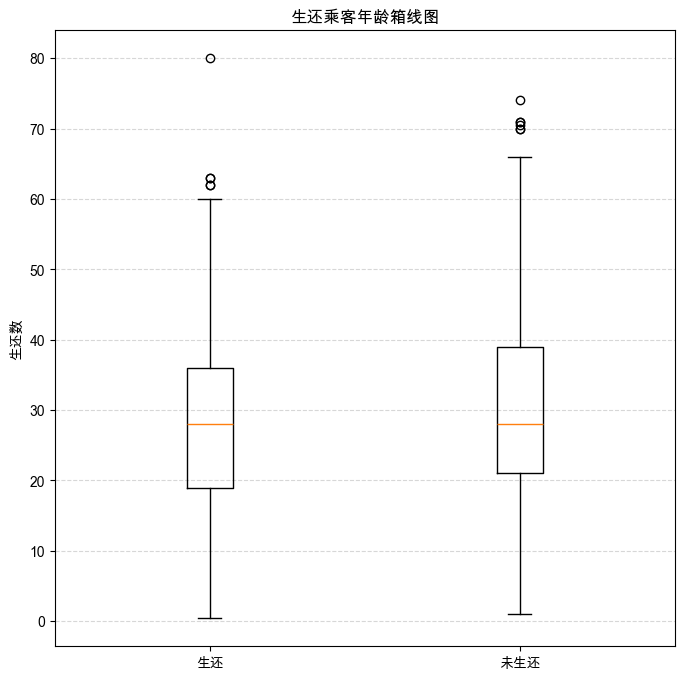

In [186]:
# 生还/未生还乘客年龄箱线图

plt.figure(figsize=(8, 8))
survive_age = df_age[(df_age['Survived'] == 1)]['Age']
notsurvive_age = df_age[(df_age['Survived'] == 0)]['Age']
data = [survive_age, notsurvive_age]
# 创建箱线图
plt.boxplot(data, tick_labels=['生还', '未生还'])

plt.title("生还乘客年龄箱线图")
plt.ylabel("年龄")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

## 5. 票价与生还率

In [231]:
# 票价分布如何？
print("1.")
print(df['Fare'].describe())
# 高票价乘客是否更容易生还？
print("2.")
print(df.groupby('Survived')[['Fare']].mean())
print("高票价乘客更容易生还")
# 票价和舱位等级之间有没有关系？
print("3.")
print(df.groupby('Pclass')[['Fare']].mean())
print("该样本体现高票价和舱位等级有明显关联")


1.
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64
2.
               Fare
Survived           
0         22.117887
1         48.395408
高票价乘客更容易生还
3.
             Fare
Pclass           
1       84.154687
2       20.662183
3       13.675550
该样本体现高票价和舱位等级有明显关联


## 6. 家庭规模与生还率

In [224]:
# 独自乘船的人多吗？
print("1.")
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print(f"独自乘船的人数为 {df['IsAlone'].sum()} 人")
# 有家庭成员同行的人是否更容易生还？
print("2.")
res1 = (df.groupby('IsAlone')['Survived'].mean() * 100).round(2)
print(res1.astype(str) + '%')
# 家庭规模太大是否反而降低生还率？
print("3.")
res2 = (df.groupby('FamilySize')['Survived'].mean() * 100).round(2)
print(res2.astype(str) + '%')

1.
独自乘船的人数为 537 人
2.
IsAlone
0    50.56%
1    30.35%
Name: Survived, dtype: object
3.
FamilySize
1     30.35%
2     55.28%
3     57.84%
4     72.41%
5      20.0%
6     13.64%
7     33.33%
8       0.0%
11      0.0%
Name: Survived, dtype: object


## 结论

1. 数据集中共有 891 名乘客，总体生还率为 38.38%。
2. 女性乘客的生还率明显高于男性乘客。
3. 一等舱乘客的生还率高于二等舱和三等舱乘客。
4. 在年龄信息完整的样本中，儿童的生还率相对较高。
5. 票价、舱位等级和家庭规模均与生还率存在关联，但本项目的分析只能说明相关性，不能证明因果关系。